## Sentiment classification
We downloaded the dataset from `kaggle` it has around `41.5k` samples.

In [1]:
# import necessary lib's

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score,
                                f1_score)

### Loading dataset ...

In [2]:
DATASET_PATH = r"E:\45DaysML\projects\sentiment-classification\datasets\sentiment_analysis_dataset.csv"

sentiment_clf_dataset = pd.read_csv(DATASET_PATH)
sentiment_clf_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41643 entries, 0 to 41642
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  41643 non-null  int64 
 1   id          41643 non-null  int64 
 2   text        41642 non-null  object
 3   label       41643 non-null  int64 
 4   sentiment   41643 non-null  object
dtypes: int64(3), object(2)
memory usage: 1.6+ MB


### How samples looks like?

In [3]:
sentiment_clf_dataset.sample(5)

,Unnamed: 0,id,text,label,sentiment
34946,3714,4962,"addin to that last comment, was spose to be go...",0,negative
18849,18849,15131,"You make me smile....it will get better, you h...",2,positive
23670,23670,4164,"The app itself gets the job done, but it will ...",0,negative
1502,1502,1367,is watching Mock the Week and is slowing cooking,1,neutral
25162,25162,27302,Have I ever told you I absolutly hate writing ...,0,negative


From the above subset, we can clearly see that the `Unnamed: 0` and `id` are of no use, so it's better if we drop these columns before going any further.
<br/>
`label` column is just the **LabelEncoder** version of `sentiment` column, therefore we can also drop the `sentiment` column as well.
<br/>
Below is how `sentiment` column **LabelEncoding** is done in `label` column.
```python
{
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}
```

In [4]:
sentiment_clf_dataset.drop(columns=['Unnamed: 0', 'id', 'sentiment'], inplace=True)

Before going any further, first check wheter these is any `nan` values present in the dataset or not.

In [5]:
sentiment_clf_dataset[sentiment_clf_dataset.isna().text]

,text,label
34983,NaN,1


Since, there is only single row, which do not contains any string value in `text` column and has `label` 1, it's better if we just remove this row and then proceed forward.
<br/>
Below given code segment does the same.

In [6]:
print("Total no. of ROWs (before dropping) : ", sentiment_clf_dataset.shape[0])
sentiment_clf_dataset.dropna(inplace=True)
print("Total no. of ROWs (after dropping) : ", sentiment_clf_dataset.shape[0])

Total no. of ROWs (before dropping) :  41643
Total no. of ROWs (after dropping) :  41642


Now that we got are our dataset in desired format, it's time to filter the input and output columns in separate variables.

In [7]:
X, y = sentiment_clf_dataset.text, sentiment_clf_dataset.label
X.shape, y.shape

((41642,), (41642,))

One last thing that we've to check is distribution of target column. If there is an imbalance distribution then, it's better to assign class weights
<br/>
Below given graph show the same.

<Axes: xlabel='label'>

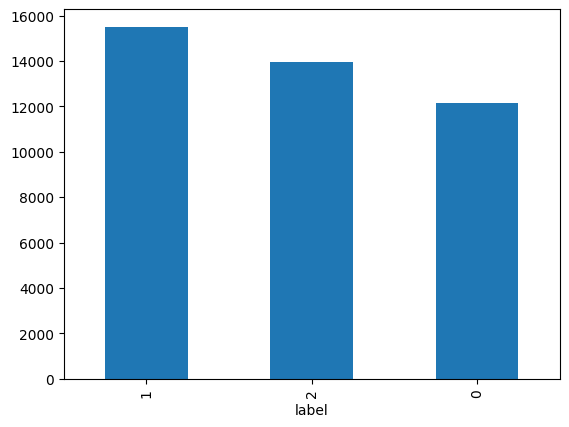

In [8]:
y.value_counts().plot(kind='bar')

There is not huge difference is the count of `label` value, but still it's good if we assign class weights. We handle this after perform the splitting of the dataset.

### Splitting dataset for training and testing

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values,
                                                     test_size=0.3,
                                                     random_state=21,
                                                     stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((29149,), (12493,), (29149,), (12493,))

In [10]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english",
                                  lowercase=True,
                                  ngram_range=(1,2),
                                   min_df=5,
                                   max_df=0.8,
                                  max_features=10000)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)

### Computing class weights

In [11]:
from sklearn.utils.class_weight import compute_sample_weight

In [12]:
weights = compute_sample_weight(class_weight="balanced", y=y_train)
len(weights)

29149

### Model training ...

In [13]:
mnb_clf = MultinomialNB(alpha=1.75)
mnb_clf.fit(X_train, y_train, sample_weight=weights)

,alpha,1.75
,force_alpha,True
,fit_prior,True
,class_prior,None


### Evaluation

In [14]:
mnb_clf_predictions = mnb_clf.predict(X_test)

In [15]:
accuracy_score(y_test, mnb_clf_predictions), f1_score(y_test, mnb_clf_predictions, average="weighted")

(0.6268310253742095, 0.6245586352763637)

From the above results we can clearly see that the model didn't perfomed great. *TBH*, it's not even close to LogisticRegression accuracy which we learned in previous class.
<br/>
But no worries, we still use this our baseline model and compare another models for better accuracy.